# Volcanic Change Detection: Reykjanes Peninsula, Iceland
### SDS210 – Programming with Spatial Data

This notebook implements a change detection workflow to identify and 
quantify landscape changes caused by the 2023–2025 Sundhnúkur eruptions 
on the Reykjanes Peninsula, Iceland.

Three research questions are investigated:
- **RQ1:** Where did the most significant landscape changes occur between 2023 and 2024?
- **RQ2:** How does embedding-based change detection compare to a traditional spectral approach?
- **RQ3:** Which critical infrastructure sites fall within the areas of highest detected landscape change?

## 1. Setup & Parameters

This section sets up the environment, defines every reusable function, configures file paths, and sets the study parameters. Functions are defined here once and called from later sections.

### 1.1 Library imports
Standard library imports plus geospatial libraries.

In [47]:
# Standard library
from pathlib import Path

# Numerical and tabular
import numpy as np
import pandas as pd

# Vector data
import geopandas as gpd

# Raster data
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.windows import Window

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cmcrameri.cm as cmc

### 1.2 Helper functions

All reusable functions are located here and will be called later in following sections.

In [48]:
def build_ocean_mask(s2_path, mndwi_threshold=0.3, window=None):
    """Water mask using MNDWI (green and SWIR1)."""
    with rasterio.open(s2_path) as src:
        band_names = list(src.descriptions)
        green = src.read(band_names.index("B3")  + 1, window=window).astype(np.float32)
        swir1 = src.read(band_names.index("B11") + 1, window=window).astype(np.float32)

    with np.errstate(divide="ignore", invalid="ignore"):
        mndwi = (green - swir1) / (green + swir1)

    return mndwi > mndwi_threshold

def compute_embedding_change(emb_pre_path, emb_post_path, window, ocean_mask):
    """Cosine similarity change map between two embedding rasters"""
    with rasterio.open(emb_pre_path) as src:
        emb_pre = src.read(masked=True, window=window).astype(np.float32)
        meta = src.profile
        meta["transform"] = src.window_transform(window)
        meta["width"]  = window.width
        meta["height"] = window.height

    with rasterio.open(emb_post_path) as src:
        emb_post = src.read(masked=True, window=window).astype(np.float32)

    # Embeddings: unit vectors
    similarity = np.sum(emb_pre * emb_post, axis=0)
    change_map = 1 - similarity

    nodata_mask = emb_pre.mask.any(axis=0) | emb_post.mask.any(axis=0) # mask: pre OR post no data
    change_map[nodata_mask] = np.nan
    change_map[ocean_mask]  = np.nan

    return change_map, meta #tuple

def compute_dnbr(s2_pre_path, s2_post_path, window, ocean_mask):
    """dNBR = pre NBR minus post NBR, from Sentinel-2 rasters"""
    with rasterio.open(s2_pre_path) as src:
        band_names = list(src.descriptions)
        nir_pre  = src.read(band_names.index("B8")  + 1, window=window).astype(np.float32)
        swir_pre = src.read(band_names.index("B12") + 1, window=window).astype(np.float32)
        meta = src.profile
        meta["transform"] = src.window_transform(window)
        meta["width"]  = window.width
        meta["height"] = window.height

    with rasterio.open(s2_post_path) as src:
        nir_post  = src.read(band_names.index("B8")  + 1, window=window).astype(np.float32)
        swir_post = src.read(band_names.index("B12") + 1, window=window).astype(np.float32)

    with np.errstate(divide="ignore", invalid="ignore"):
        nbr_pre  = (nir_pre  - swir_pre)  / (nir_pre  + swir_pre)
        nbr_post = (nir_post - swir_post) / (nir_post + swir_post)

    dnbr = nbr_pre - nbr_post
    dnbr[ocean_mask] = np.nan

    return dnbr, meta

def save_change_raster(data, meta, output_path):
    """Write a single-band change map to disk as a GeoTIFF"""
    meta = meta.copy()
    meta.update(count=1, dtype="float32", nodata=np.nan)
    with rasterio.open(output_path, "w", **meta) as dst: # opens file for writing & unpacks profile dictionary as keyword arguments (driver, width, height, CRS, transform, etc.)
        dst.write(data.astype("float32"), 1)

def load_sentinel2_rgb(s2_path, window=None, vmax=3000):
    """Build a true-color background image from Sentinel-2."""
    with rasterio.open(s2_path) as src:
        band_names = list(src.descriptions)
        red   = src.read(band_names.index("B4") + 1, window=window).astype(float)
        green = src.read(band_names.index("B3") + 1, window=window).astype(float)
        blue  = src.read(band_names.index("B2") + 1, window=window).astype(float)

    red_n   = np.clip(red,   0, vmax) / vmax
    green_n = np.clip(green, 0, vmax) / vmax
    blue_n  = np.clip(blue,  0, vmax) / vmax

    return np.dstack((red_n, green_n, blue_n))

def reproject_to_crs(gdf, target_crs):
    """Reproject a GeoDataFrame/Vector data to target CRS."""
    if gdf.crs != target_crs:
        return gdf.to_crs(target_crs)
    return gdf

def get_mean_value_per_building(raster_path, buildings_gdf, column_name):
    """Compute mean raster value beneath each building footprint (zonal statistics)."""
    means = [] #create list
    with rasterio.open(raster_path) as src:
        for idx, row in buildings_gdf.iterrows(): # loop
            out_image, _ = mask(src, [row.geometry], crop=True, nodata=np.nan) #rasterizes geometry against source grid
            valid = out_image[~np.isnan(out_image)]
            if valid.size == 0:
                means.append(np.nan)
            else:
                means.append(float(valid.mean()))
    result = buildings_gdf.copy()
    result[column_name] = means
    return result

### 1.3 File paths
All input and output paths are defined here so files can be located from a single point.

In [49]:
DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
OUTPUT_DIR     = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Raster files exported from GEE
EMB_2023 = DATA_RAW / "AEF_embedding_2023.tif"
EMB_2024 = DATA_RAW / "AEF_embedding_2024.tif"
S2_2023  = DATA_RAW / "S2_composite_2023.tif"
S2_2024  = DATA_RAW / "S2_composite_2024.tif"

# Vector files
BUILDINGS_PRE      = DATA_RAW / "buildings_pre_eruption.geojson"
BUILDINGS_POST     = DATA_RAW / "buildings_post_eruption.geojson"
BUILDINGS_COMBINED = DATA_PROCESSED / "buildings_combined.geojson"

# Output rasters
CHANGE_MAP_PATH = OUTPUT_DIR / "rq1_change_map.tif"
DNBR_MAP_PATH   = OUTPUT_DIR / "rq2_dnbr_map.tif"
CHANGE_MASK_PATH = OUTPUT_DIR / "rq2_change_mask.tif"

### 1.4 Study parameters
All thresholds, study extent and changable constants are here.

In [50]:
AOI_NAME  = "Reykjanes Peninsula, Iceland"
YEAR_PRE  = 2023
YEAR_POST = 2024

# Change detection thresholds
CHANGE_THRESHOLD = 0.3    # embedding cosine change
DNBR_THRESHOLD   = 0.3   # spectral dNBR

# Ocean mask
MNDWI_THRESHOLD = 0.3      # > this = water

# Crop window: skip empty western area
COL_CROP_START = 200

print(f"Study area:   {AOI_NAME}")
print(f"Before/after: {YEAR_PRE} to {YEAR_POST}")

Study area:   Reykjanes Peninsula, Iceland
Before/after: 2023 to 2024


## 2. Data Loading

Inspect the raw raster files exported from Google Earth Engine to confirm CRS, band counts, and dimensions. Vector data (buildings) is loaded later in Section 6 where it is used.

In [51]:
for filepath in [EMB_2023, EMB_2024, S2_2023, S2_2024]:
    with rasterio.open(filepath) as src:
        print(f"{filepath.name}")
        print(f"  CRS:   {src.crs}")
        print(f"  Bands: {src.count}")
        print(f"  Shape: {src.height} x {src.width}")

AEF_embedding_2023.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
AEF_embedding_2024.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
S2_composite_2023.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346
S2_composite_2024.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346


## 3. Inspection & Cleaning

Two preparatory steps are taken before any analysis:

1. **Build the crop window** to remove the empty western area of the AOI that contains no eruption-relevant data.
2. **Build the ocean mask** from the 2023 Sentinel-2 image using MNDWI. The mask is later applied to all change maps to remove water and coastal noise.

In [52]:
# Build the crop window once and reuse everywhere
with rasterio.open(EMB_2023) as src:
    CROP_WINDOW = Window(
        col_off=COL_CROP_START,
        row_off=0,
        width=src.width - COL_CROP_START,
        height=src.height
    )

print(f"Crop window: {CROP_WINDOW.height} x {CROP_WINDOW.width}")

# Build ocean mask from 2023 Sentinel-2
ocean_mask = build_ocean_mask(S2_2023, MNDWI_THRESHOLD, window=CROP_WINDOW)
print(f"Ocean pixels masked: {ocean_mask.sum():,} "
      f"({100 * ocean_mask.sum() / ocean_mask.size:.1f}%)")

Crop window: 1723 x 2146
Ocean pixels masked: 765,928 (20.7%)


## 4. RQ1 — Embedding-based change

This section answers RQ1 by computing where the most significant landscape changes occurred between 2023 and 2024 based on AI supported embeddings.

The computation is done in a single loop that processes both methods (embedding and dNBR), since RQ2 will need the dNBR result too. Both change maps are saved to disk for use in RQ3. Only the embedding-based map is visualized here.

In [53]:
change_results = {} #set up dictionary

methods = [
    ("embedding", compute_embedding_change, EMB_2023, EMB_2024, CHANGE_MAP_PATH),
    ("dnbr",      compute_dnbr,             S2_2023,  S2_2024,  DNBR_MAP_PATH),
] # list containing tuples. 

for name, compute_func, pre_path, post_path, save_path in methods: # Loop
    data, meta = compute_func(pre_path, post_path, CROP_WINDOW, ocean_mask)

    # Rescale to [0, 1]: clip negatives, then divide by max
    data = np.clip(data, 0, None)
    data_max = np.nanmax(data)
    data = data / data_max

    save_change_raster(data, meta, save_path)
    change_results[name] = (data, meta)
    print(f"{name:9s}: rescaled to [0, 1] (original max = {data_max:.4f})")


# Short names
change_map, emb_meta  = change_results["embedding"]
dnbr,       dnbr_meta = change_results["dnbr"]

embedding: rescaled to [0, 1] (original max = 0.5348)
dnbr     : rescaled to [0, 1] (original max = 0.8536)


### 4.1 Visualize the embedding change map
Pixels with high values indicate strong landscape change between 2023 and 2024. The dark areas covering the southern half of the AOI are the lava flows from the Sundhnúkur eruption series.

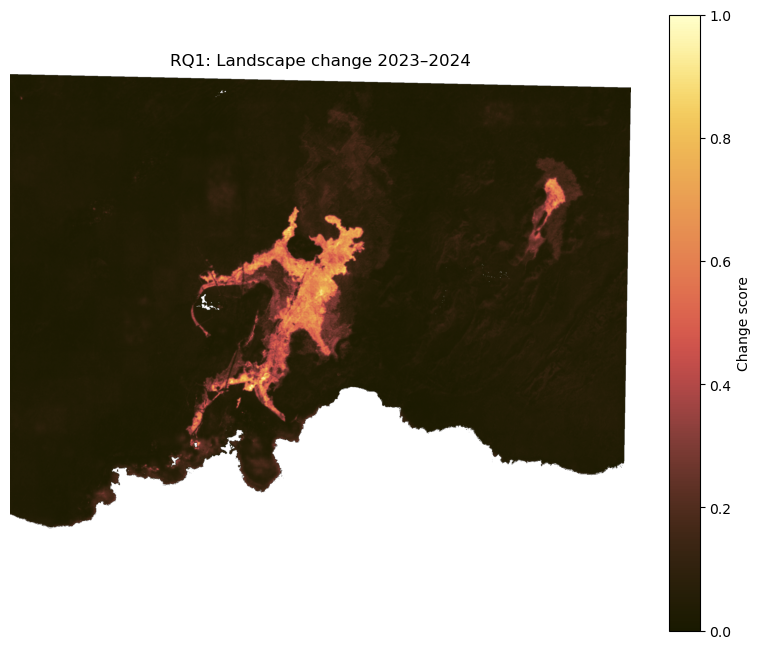

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=1)
fig.colorbar(img, ax=ax, label="Change score")
ax.set_title(f"RQ1: Landscape change {YEAR_PRE}–{YEAR_POST}")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq1_change_map.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. RQ2 — Method comparison

Compare the embedding-based change map with a traditional spectral approach (dNBR). Three outputs can be seen:

1. A side-by-side plot of both methods.
2. An agreement map showing where the methods agree on change, where each method detects change alone, and where they detect no change.
3. The percentage breakdown of agreement categories.

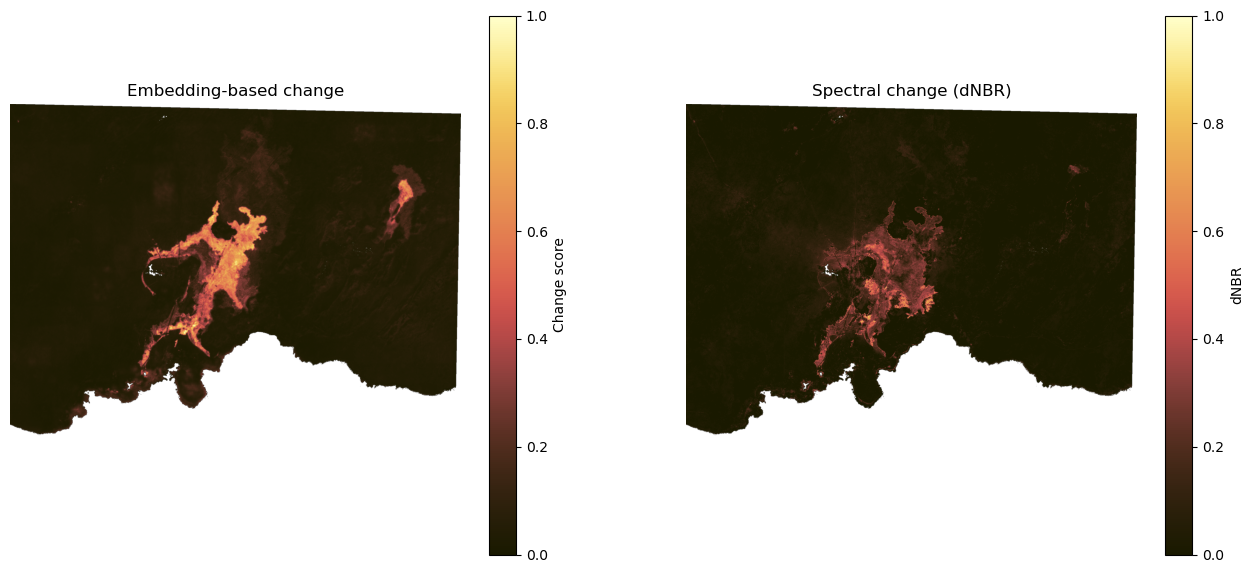

In [55]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

img1 = axs[0].imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=1)
fig.colorbar(img1, ax=axs[0], label="Change score")
axs[0].set_title("Embedding-based change")
axs[0].axis("off")

img2 = axs[1].imshow(dnbr, cmap=cmc.lajolla, vmin=0, vmax=1)
fig.colorbar(img2, ax=axs[1], label="dNBR")
axs[1].set_title("Spectral change (dNBR)")
axs[1].axis("off")

fig.savefig(OUTPUT_DIR / "rq2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.1 Method agreement map
A pixel-wise comparison between the two methods. Categories:

- **Embedding only:** the embedding detected change, dNBR did not.
- **dNBR only:** dNBR detected change, the embedding did not.
- **Both (consensus):** both methods detected change.
- **Neither (transparent):** the background image shows through.

Both methods agree (changed):    0.86%
Embedding only:                  3.25%
dNBR only:                       1.07%
Neither (no change):             94.81%


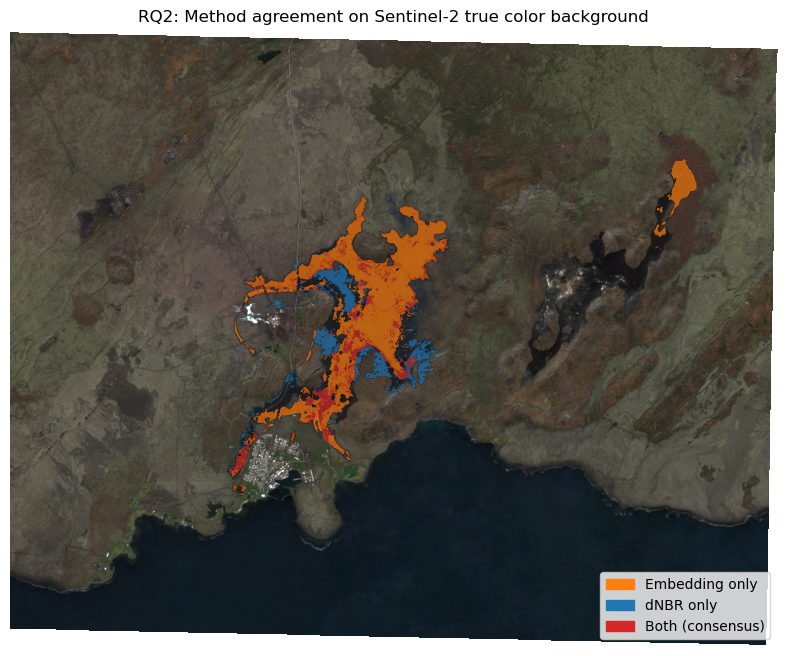

In [56]:
# Binary masks
emb_changed  = change_map >= CHANGE_THRESHOLD
dnbr_changed = dnbr       >= DNBR_THRESHOLD

# 0=neither, 1=embedding only, 2=dNBR only, 3=both
agreement = np.zeros_like(change_map, dtype=int)
agreement[emb_changed  & ~dnbr_changed] = 1
agreement[~emb_changed &  dnbr_changed] = 2
agreement[emb_changed  &  dnbr_changed] = 3

# Percentages
valid_pixels = ~np.isnan(change_map) & ~np.isnan(dnbr)
total = valid_pixels.sum()
print(f"Both methods agree (changed):    {(agreement == 3).sum() / total * 100:.2f}%")
print(f"Embedding only:                  {(agreement == 1).sum() / total * 100:.2f}%")
print(f"dNBR only:                       {(agreement == 2).sum() / total * 100:.2f}%")
print(f"Neither (no change):             {(agreement == 0).sum() / total * 100:.2f}%")

# Visualization with RGB background
true_color = load_sentinel2_rgb(S2_2024, window=CROP_WINDOW)
agreement_visible = np.where(agreement >= 1, agreement, np.nan)
cmap = ListedColormap(["tab:orange", "tab:blue", "tab:red"])

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(true_color)
ax.imshow(agreement_visible, cmap=cmap, vmin=1, vmax=3, alpha=0.7)

legend_handles = [
    mpatches.Patch(color="tab:orange", label="Embedding only"),
    mpatches.Patch(color="tab:blue",   label="dNBR only"),
    mpatches.Patch(color="tab:red",    label="Both (consensus)")
]
ax.legend(handles=legend_handles, loc="lower right")

ax.set_title("RQ2: Method agreement on Sentinel-2 true color background")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq2_agreement_map.png", dpi=300, bbox_inches="tight")
plt.show()

# Save binary change mask (1 = any method detected change, NaN = nodata/ocean)
change_mask_data = (agreement >= 1).astype(np.float32)
change_mask_data[np.isnan(change_map)] = np.nan
save_change_raster(change_mask_data, emb_meta, CHANGE_MASK_PATH) # saving as GeoTIFF

## 6. RQ3 — Infrastructure impact

This section is the only place vector data is used, so building footprints are loaded here. OSM data is downloaded both as a pre-eruption (Nov 2023) and current snapshot. Three categories of buildings emerge:

- **Existing**: present in both snapshots — survived structures
- **Removed/Destroyed**: present only in pre — likely removed from OSM after destruction
- **Newly mapped**: present only in post — physically existed before but were added to OSM later

A building is classified as **affected** if either the embedding or the dNBR map detects significant change at its location.

In [57]:
# Load OSM building files
buildings_pre  = gpd.read_file(BUILDINGS_PRE)
buildings_post = gpd.read_file(BUILDINGS_POST)

# Reproject to the raster CRS using the helper function
with rasterio.open(EMB_2023) as src:
    raster_crs = src.crs

buildings_pre  = reproject_to_crs(buildings_pre,  raster_crs)
buildings_post = reproject_to_crs(buildings_post, raster_crs)

# Identify each category by OSM ID + create Set
pre_ids  = set(buildings_pre["id"])
post_ids = set(buildings_post["id"])

existing_ids     = pre_ids & post_ids
removed_ids    = pre_ids - post_ids
newly_mapped_ids = post_ids - pre_ids

# Combine into one GeoDataFrame
buildings_combined = pd.concat([buildings_pre, buildings_post])
buildings_combined = buildings_combined.drop_duplicates(subset=["id"])
buildings_combined = gpd.GeoDataFrame(buildings_combined, crs=raster_crs)

# Tag each building with its status
buildings_combined["status"] = "existing"
buildings_combined.loc[buildings_combined["id"].isin(removed_ids),    "status"] = "removed"
buildings_combined.loc[buildings_combined["id"].isin(newly_mapped_ids), "status"] = "newly_mapped"

# converts crop window into coordinate bounds
with rasterio.open(EMB_2023) as src:
    cropped_bounds = rasterio.windows.bounds(CROP_WINDOW, src.transform)
# get coordinates from middle point of building + test if its in bounding box
within_extent = (
    (buildings_combined.geometry.centroid.x >= cropped_bounds[0]) &
    (buildings_combined.geometry.centroid.x <= cropped_bounds[2]) &
    (buildings_combined.geometry.centroid.y >= cropped_bounds[1]) &
    (buildings_combined.geometry.centroid.y <= cropped_bounds[3])
)
buildings_combined = buildings_combined[within_extent].copy()

buildings_combined.to_file(BUILDINGS_COMBINED, driver="GeoJSON")

print(f"Existing (in both):     {len(existing_ids)}")
print(f"Removed (only pre):   {len(removed_ids)}")
print(f"Newly mapped (only post): {len(newly_mapped_ids)}")
print(f"Total combined:         {len(buildings_combined)}")

Existing (in both):     1299
Removed (only pre):   7
Newly mapped (only post): 84
Total combined:         1389


### 6.1 Classify buildings by overlap with the RQ2 change mask

A building is classified as **affected** if its footprint overlaps with any pixel flagged as "changed" in the RQ2 agreement map.

In [58]:
# Check what fraction of each building's footprint overlaps the RQ2 change mask
buildings_with_change = get_mean_value_per_building(
    CHANGE_MASK_PATH, buildings_combined, "overlap_fraction"
)

# A building is affected if ANY of its pixels overlap a flagged-change pixel
buildings_with_change["change_class"] = "unaffected"
buildings_with_change.loc[
    buildings_with_change["overlap_fraction"] > 0, "change_class"
] = "affected"

# Summary
n_affected = (buildings_with_change["change_class"] == "affected").sum()
n_total = len(buildings_with_change)
print(f"Total buildings: {n_total}")
print(f"Affected:        {n_affected} ({100 * n_affected / n_total:.1f}%)")

buildings_with_change.to_file(
    OUTPUT_DIR / "rq3_buildings_with_change.geojson", driver="GeoJSON"
)

Total buildings: 1389
Affected:        4 (0.3%)


### 6.2 Visualize affected buildings

Plot affected buildings in red on a Sentinel-2 true color background. Affected buildings are buffered by two pixels so they remain visible at full-map zoom.

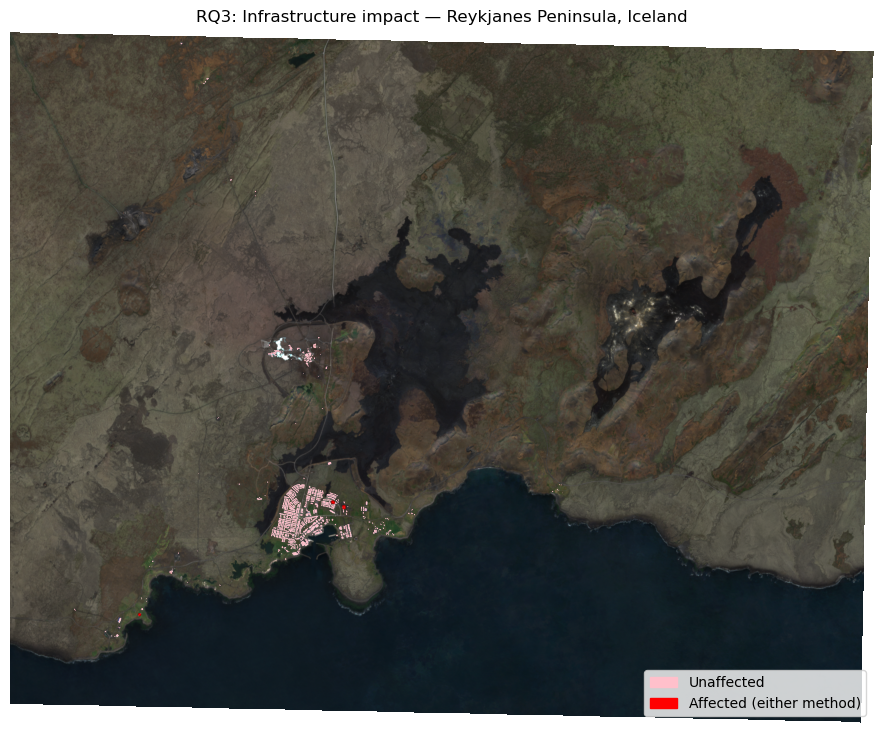

In [59]:
# Same RGB background as RQ2
true_color = load_sentinel2_rgb(S2_2024, window=CROP_WINDOW)

# Get cropped bounds for georeferenced plotting
with rasterio.open(EMB_2023) as src:
    cropped_bounds = rasterio.windows.bounds(CROP_WINDOW, src.transform)

# Build the extent in (left, right, bottom, top) order for imshow
extent = (cropped_bounds[0], cropped_bounds[2], cropped_bounds[1], cropped_bounds[3])

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(true_color, extent=extent)

unaffected = buildings_with_change[buildings_with_change["change_class"] == "unaffected"]
affected   = buildings_with_change[buildings_with_change["change_class"] == "affected"]

# Buffer affected buildings by 30 m so they are visible on the map
affected_buffered = affected.copy()
affected_buffered["geometry"] = affected.buffer(30)

unaffected.plot(ax=ax, color="pink", alpha=1, edgecolor="pink", linewidth=0.3)
affected_buffered.plot(ax=ax, color="red", alpha=0.9, edgecolor="darkred", linewidth=0.4)

legend_handles = [
    mpatches.Patch(color="pink", label="Unaffected"),
    mpatches.Patch(color="red",   label="Affected (either method)")
]
ax.legend(handles=legend_handles, loc="lower right")
ax.set_title(f"RQ3: Infrastructure impact — {AOI_NAME}")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq3_infrastructure.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Summary

### Interpretation
- The embedding-based change map and the dNBR map both highlight the Sundhnúkur fissure area and the lava flows toward Grindavík.
- The dNBR map is more focused on general surface reflectance change, making an accurate detection of fresh lava against old lava difficult, while the embedding map captures a broader notion of landscape change, making it an ideal uscase when accurate distictions between new and fresh surface changes want to be mapped. 

### Limitations
- The Sentinel-2 images are seasonal composites, that  cannot distinguish between the individual eruption events of 2024.
- OSM building footprints depend on voluntary mapping and may miss small or recently destroyed structures. Another  option is that buildings got removed out of other reasons than destruction.
- Cloud cover in Iceland is high; the May–September Sentinel-2 composite mitigates but does not fully remove this (MNDWI required).